# End-to-End Usage Example
This notebook demonstrates a full workflow for `transform_emr`: install/import, data preparation, train/load (Phase 1 + Phase 2), and evaluation.

In [1]:
%pip install -e .

Obtaining file:///C:/Users/shaha/Work/Personal/Transform-EMR
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for transform_emr (pyproject.toml): started
  Building editable for transform_emr (pyproject.toml): finished with status 'done'
  Created wheel for transform_emr: filename=transform_emr-0.1-0.editable-py3-none-any.whl size=3982 sha256=7e922880406070f5f05fa8cf81cd7694d2fb1dc6da113a02f4f1d8f48d840250
  Stored in directory: C:\Users\shaha\AppData\Local\Temp\pip-ephem-wheel-cache-2ix4x5h9\wheels\6d\6c\f9\48dfb1d8b6464f43416

In [ ]:
import importlib
import random
import sys
from pathlib import Path

import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import transform_emr.config.dataset_config as dataset_config
import transform_emr.config.model_config as model_config
from transform_emr import dataset, embedder, transformer, inference, diagnose

# Preserve runtime overrides before reload (useful when Cell 6 is expensive to rerun).
_runtime_model_config = dict(getattr(model_config, "MODEL_CONFIG", {}))
_runtime_training_settings = dict(getattr(model_config, "TRAINING_SETTINGS", {}))
_runtime_filter_criteria = getattr(dataset_config, "INCLUSION_EXCLUSION_CRITERIA", None)

for module in (
    dataset_config,
    model_config,
    dataset,
    embedder,
    transformer,
    inference,
    diagnose
):
    importlib.reload(module)

# Restore runtime config values after reload.
if hasattr(model_config, "MODEL_CONFIG") and _runtime_model_config:
    model_config.MODEL_CONFIG.update(_runtime_model_config)
if hasattr(model_config, "TRAINING_SETTINGS") and _runtime_training_settings:
    model_config.TRAINING_SETTINGS.update(_runtime_training_settings)
if _runtime_filter_criteria is not None and hasattr(dataset_config, "INCLUSION_EXCLUSION_CRITERIA"):
    dataset_config.INCLUSION_EXCLUSION_CRITERIA = _runtime_filter_criteria

print("Reloaded config and modules with runtime config overrides preserved.")
print(f"Project root: {PROJECT_ROOT}")
print(f"MODEL_CONFIG['ctx_dim'] = {model_config.MODEL_CONFIG.get('ctx_dim')}")

c:\Users\shaha\Work\Personal\Transform-EMR\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reloaded config and modules with runtime config overrides preserved.
Project root: C:\Users\shaha\Work\Personal\Transform-EMR
MODEL_CONFIG['ctx_dim'] = None


In [3]:
# Optional cleanup controls for checkpoint artifacts (useful on restricted VMs)
CLEAN_SCALER = False
CLEAN_TOKENIZER = False
CLEAN_EMBEDDER = False
CLEAN_TRANSFORMER = False

# Convenience switch: if True, cleans all artifacts above
CLEAN_ALL = True

clean_scaler = CLEAN_SCALER or CLEAN_ALL
clean_tokenizer = CLEAN_TOKENIZER or CLEAN_ALL
clean_embedder = CLEAN_EMBEDDER or CLEAN_ALL
clean_transformer = CLEAN_TRANSFORMER or CLEAN_ALL

paths_to_delete = []

if clean_scaler:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "scaler.pkl")
if clean_tokenizer:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt")
if clean_embedder:
    embedder_ckpt = Path(model_config.PHASE1_CHECKPOINT).resolve()
    paths_to_delete.extend([embedder_ckpt, embedder_ckpt.parent / "ckpt_last.pt"])
if clean_transformer:
    transformer_ckpt = Path(model_config.PHASE2_CHECKPOINT).resolve()
    paths_to_delete.extend([transformer_ckpt, transformer_ckpt.parent / "ckpt_last.pt"])
    transformer_ckpt = Path(model_config.PHASE3_CHECKPOINT).resolve()
    paths_to_delete.extend([transformer_ckpt, transformer_ckpt.parent / "ckpt_last.pt"])

if not paths_to_delete:
    print("No cleanup selected. Set CLEAN_* = True (or CLEAN_ALL = True) and re-run this cell.")
else:
    removed, missing, failed = [], [], []
    for path in dict.fromkeys(paths_to_delete):  # dedupe while preserving order
        try:
            if path.exists():
                path.unlink()
                removed.append(path)
            else:
                missing.append(path)
        except Exception as exc:
            failed.append((path, str(exc)))

    print("Checkpoint cleanup summary:")
    print(f"  Removed: {len(removed)}")
    for path in removed:
        print(f"    - {path}")

    print(f"  Not found: {len(missing)}")
    for path in missing:
        print(f"    - {path}")

    if failed:
        print(f"  Failed: {len(failed)}")
        for path, err in failed:
            print(f"    - {path} -> {err}")

Checkpoint cleanup summary:
  Removed: 2
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\scaler.pkl
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\tokenizer.pt
  Not found: 6
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_last.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase2\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase2\ckpt_last.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_last.pt


## 1) Data Load and Processing

In [4]:
# Data Source
# DATA_SOURCE_MODE:
#   "pre_split" use TRAIN_* / TEST_* files from dataset_config (recommended for VM runs)
#   "source_split" load from data/source/, split by PatientId, optionally save splits
DATA_SOURCE_MODE = "pre_split"

if DATA_SOURCE_MODE not in {"pre_split", "source_split"}:
    raise ValueError("DATA_SOURCE_MODE must be 'pre_split' or 'source_split'.")

SOURCE_TEMPORAL_DATA_FILE = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_temporal_data.csv"
SOURCE_CTX_DATA_FILE      = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_context_data.csv"
SOURCE_TEST_SIZE   = 0.2
SOURCE_SPLIT_SEED  = 42
CONTEXT_COLUMN_RENAME_MAP = {}
CONTEXT_COLUMNS_TO_DROP   = []
SAVE_SOURCE_SPLITS = True
SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE = PROJECT_ROOT / "data" / "train" / "synthetic_diabetes_temporal_data.csv"
SOURCE_OUTPUT_TRAIN_CTX_FILE      = PROJECT_ROOT / "data" / "train" / "synthetic_diabetes_context_data.csv"
SOURCE_OUTPUT_TEST_TEMPORAL_FILE  = PROJECT_ROOT / "data" / "test"  / "synthetic_diabetes_temporal_data.csv"
SOURCE_OUTPUT_TEST_CTX_FILE       = PROJECT_ROOT / "data" / "test"  / "synthetic_diabetes_context_data.csv"

# Train/Val split settings
TRAIN_VAL_SIZE       = 0.2
TRAIN_VAL_SPLIT_SEED = 42

# Optional patient sampling (None = all)
SAMPLE_PATIENTS = None
NUM_WORKERS = 4 if SAMPLE_PATIENTS is None else 0

# Tokenizer
TOKENIZER_PATH     = Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt"
TOKENIZER_FIT_SCOPE = "all_processed"   # "train_only" | "train_val" | "all_processed"

# Misc
AUTO_SET_CTX_DIM = True
K_RANGE          = range(3, 8)
MAX_LEN          = 1000
TEMPERATURE      = 1.0
TIME_BIAS_HOURS  = 48

print(f"Data mode: {DATA_SOURCE_MODE}")

# Load raw data
if DATA_SOURCE_MODE == "pre_split":
    train_temporal_raw = pd.read_csv(dataset_config.TRAIN_TEMPORAL_DATA_FILE, low_memory=False)
    train_ctx_raw      = pd.read_csv(dataset_config.TRAIN_CTX_DATA_FILE)
    eval_temporal_raw  = pd.read_csv(dataset_config.TEST_TEMPORAL_DATA_FILE,  low_memory=False)
    eval_ctx_raw       = pd.read_csv(dataset_config.TEST_CTX_DATA_FILE)
else:
    source_temporal_raw = pd.read_csv(SOURCE_TEMPORAL_DATA_FILE, low_memory=False)
    source_ctx_raw      = pd.read_csv(SOURCE_CTX_DATA_FILE)
    if CONTEXT_COLUMN_RENAME_MAP:
        source_ctx_raw = source_ctx_raw.rename(columns=CONTEXT_COLUMN_RENAME_MAP)
    if CONTEXT_COLUMNS_TO_DROP:
        source_ctx_raw = source_ctx_raw.drop(columns=CONTEXT_COLUMNS_TO_DROP, errors="ignore")
    source_pids = source_temporal_raw["PatientId"].dropna().unique()
    train_pool_ids, eval_ids = train_test_split(
        source_pids, test_size=SOURCE_TEST_SIZE, random_state=SOURCE_SPLIT_SEED)
    train_temporal_raw = source_temporal_raw[source_temporal_raw["PatientId"].isin(train_pool_ids)].copy()
    train_ctx_raw      = source_ctx_raw[source_ctx_raw["PatientId"].isin(train_pool_ids)].copy()
    eval_temporal_raw  = source_temporal_raw[source_temporal_raw["PatientId"].isin(eval_ids)].copy()
    eval_ctx_raw       = source_ctx_raw[source_ctx_raw["PatientId"].isin(eval_ids)].copy()
    if SAVE_SOURCE_SPLITS:
        for p in [SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE, SOURCE_OUTPUT_TRAIN_CTX_FILE,
                  SOURCE_OUTPUT_TEST_TEMPORAL_FILE, SOURCE_OUTPUT_TEST_CTX_FILE]:
            p.parent.mkdir(parents=True, exist_ok=True)
        train_temporal_raw.to_csv(SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE, index=False)
        train_ctx_raw.to_csv(SOURCE_OUTPUT_TRAIN_CTX_FILE, index=False)
        eval_temporal_raw.to_csv(SOURCE_OUTPUT_TEST_TEMPORAL_FILE, index=False)
        eval_ctx_raw.to_csv(SOURCE_OUTPUT_TEST_CTX_FILE, index=False)

if SAMPLE_PATIENTS is not None:
    sampled_ids = sorted(random.sample(list(train_temporal_raw["PatientId"].dropna().unique()), SAMPLE_PATIENTS))
    train_temporal_raw = train_temporal_raw[train_temporal_raw["PatientId"].isin(sampled_ids)].copy()
    train_ctx_raw      = train_ctx_raw[train_ctx_raw["PatientId"].isin(sampled_ids)].copy()

# Process full train pool (fits scaler; enables stratified split on processed tokens)
print("Processing full train pool (fits scaler)...")
train_pool_processor = dataset.DataProcessor(
    train_temporal_raw.copy(), train_ctx_raw.copy(),
    scaler=None,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
)
train_pool_df, train_pool_ctx_df = train_pool_processor.run()

scaler_path = Path(model_config.CHECKPOINT_PATH) / "scaler.pkl"
if not scaler_path.exists():
    raise FileNotFoundError(f"Expected scaler at {scaler_path}")
scaler = joblib.load(scaler_path)

# Build / load tokenizer
if TOKENIZER_PATH.exists():
    print(f"Loading tokenizer from: {TOKENIZER_PATH}")
    tokenizer = dataset.EMRTokenizer.load(TOKENIZER_PATH)
else:
    print("Processing eval split for tokenizer fitting...")
    eval_proc_df = dataset.DataProcessor(
        eval_temporal_raw.copy(), eval_ctx_raw.copy(),
        scaler=scaler,
        tak_repo_path=dataset_config.TAK_REPO_PATH,
        checkpoint_path=model_config.CHECKPOINT_PATH,
    ).run()[0]

    if TOKENIZER_FIT_SCOPE == "train_only":
        tokenizer_fit_df = train_pool_df
    elif TOKENIZER_FIT_SCOPE == "train_val":
        tokenizer_fit_df = train_pool_df   # val not yet processed; use full pool as approximation
    else:
        tokenizer_fit_df = pd.concat([train_pool_df, eval_proc_df], ignore_index=True)

    print(f"Building tokenizer ({TOKENIZER_FIT_SCOPE}): "
          f"{tokenizer_fit_df['PatientId'].nunique()} patients, "
          f"{tokenizer_fit_df['PositionToken'].nunique()} unique tokens")
    tokenizer = dataset.EMRTokenizer.from_processed_df(tokenizer_fit_df)
    tokenizer.save(TOKENIZER_PATH)
    print(f"Saved tokenizer to: {TOKENIZER_PATH}")

# Stratified train/val split
# Strata key = each patient's rarest valid outcome (by prevalence ratio).
# Guarantees at least one representative of each kept outcome in both train and val.
train_pool_pids = train_pool_df["PatientId"].dropna().unique()
patient_tokens_map = train_pool_df.groupby("PatientId")["PositionToken"].apply(set)
strat_labels = []
for pid in train_pool_pids:
    patient_outcomes = [n for n in dataset_config.OUTCOMES if n in patient_tokens_map.get(pid, set())]
    if patient_outcomes and tokenizer.outcome_patient_ratios:
        rarest = min(patient_outcomes, key=lambda n: tokenizer.outcome_patient_ratios.get(n, 1.0))
        strat_labels.append(rarest)
    else:
        strat_labels.append("__common__")

train_ids, val_ids = train_test_split(
    train_pool_pids, test_size=TRAIN_VAL_SIZE, random_state=TRAIN_VAL_SPLIT_SEED,
    stratify=strat_labels,
)

# Slice already-processed data; reprocess val with fitted scaler
train_temporal_df = train_pool_df[train_pool_df["PatientId"].isin(train_ids)].copy()
train_ctx_df      = train_pool_ctx_df[train_pool_ctx_df.index.isin(train_ids)].copy()

val_temporal_raw  = train_temporal_raw[train_temporal_raw["PatientId"].isin(val_ids)].copy()
val_ctx_raw       = train_ctx_raw[train_ctx_raw["PatientId"].isin(val_ids)].copy()
print("Processing val split (uses fitted scaler)...")
val_temporal_df, val_ctx_df = dataset.DataProcessor(
    val_temporal_raw, val_ctx_raw,
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
).run()

print("Processing eval split (uses fitted scaler)...")
eval_temporal_df, eval_ctx_df = dataset.DataProcessor(
    eval_temporal_raw.copy(), eval_ctx_raw.copy(),
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
).run()

# Build datasets
train_ds = dataset.EMRDataset(train_temporal_df, train_ctx_df, tokenizer=tokenizer)
val_ds   = dataset.EMRDataset(val_temporal_df,   val_ctx_df,   tokenizer=tokenizer)
eval_ds  = dataset.EMRDataset(eval_temporal_df,  eval_ctx_df,  tokenizer=tokenizer)

if AUTO_SET_CTX_DIM:
    model_config.MODEL_CONFIG["ctx_dim"] = int(train_ds.context_df.shape[1])
    print(f"Updated MODEL_CONFIG['ctx_dim'] -> {model_config.MODEL_CONFIG['ctx_dim']}")

print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Eval patients: {eval_temporal_df['PatientId'].nunique()}")
print(f"Train records: {len(train_ds.tokens_df):,} | Val records: {len(val_ds.tokens_df):,} | Eval records: {len(eval_ds.tokens_df):,}")


Data mode: pre_split
Processing full train pool (fits scaler)...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 147658 -> 147658
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 147658 -> 131054
Processing eval split for tokenizer fitting...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 31254 -> 31254
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 31254 -> 27852
Building tokenizer (all_processed): 500 patients, 374 unique tokens
Saved tokenizer to: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\tokenizer.pt
Processing val split (uses fitted scaler)...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 29134 -> 29134
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 29134 -> 25844
Processing eval split (uses fitted scaler)...
[DataProcessor] Applied temporal filter: WH

## 2) Training

In [ ]:
# Training Control Panel
#
# RUN_PHASE1 : Whether to run Phase-1 (embedder) training.
#              True  -> train the embedder (fresh or resumed per RESUME_TRAINING).
#              False -> skip; best available Phase-1 checkpoint is loaded instead.
#
# RUN_PHASE2 : Whether to run Phase-2 (transformer) training.
#              True  -> train the transformer (fresh or resumed per RESUME_TRAINING).
#              False -> skip; best available Phase-2 checkpoint is loaded instead.
#
# RUN_PHASE3 : Whether to run Phase-3 (outcome head alignment).
#              True  -> fine-tune outcome_head on free-running trajectories.
#              False -> skip; loads Phase-3 checkpoint if available, otherwise uses
#                      Phase-2 outcome head (may have teacher-forcing distribution gap).
#
# RESUME_TRAINING : Whether each active phase continues from its last checkpoint.
#              True  -> restore weights + optimizer + scheduler + aux-scheduler and continue.
#              False -> start that phase from epoch 0 with fresh optimizer/scheduler state.
#              (Has no effect on phases that are skipped -- those always load best checkpoint.)
#
#
# Common configurations:
#   Full fresh start             RUN_PHASE1=True,  RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=False
#   Resume all phases            RUN_PHASE1=True,  RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=True
#   Skip phase 1, fresh ph.2-3   RUN_PHASE1=False, RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=False
#   Phase 3 only (post-training) RUN_PHASE1=False, RUN_PHASE2=False, RUN_PHASE3=True,  RESUME_TRAINING=True
#   Evaluate only (no training)  RUN_PHASE1=False, RUN_PHASE2=False, RUN_PHASE3=False, RESUME_TRAINING=False

RUN_PHASE1      = True
RUN_PHASE2      = True
RUN_PHASE3      = True
RESUME_TRAINING = True

print(f"RUN_PHASE1={RUN_PHASE1}  |  RUN_PHASE2={RUN_PHASE2}  |  RUN_PHASE3={RUN_PHASE3}  |  RESUME_TRAINING={RESUME_TRAINING}")

RUN_PHASE1=True  |  RUN_PHASE2=True  |  RUN_PHASE3=True  |  RESUME_TRAINING=True
EVAL_INPUT_DAYS=2


In [10]:
# DataLoaders
# All DataLoader construction lives here so phases can be re-run independently
# by re-executing only this cell and the training cell below.
#
# Phase 2 uses oversample=True + bucket_batching=True (WeightedBucketBatchSampler):
#   draws indices with rare-outcome weights, then sorts by length to minimise padding.
#   pos_weight is omitted from OutcomeCriterion  the sampler already rebalances.
# Phases 1 and 3 share train_dl (natural distribution, bucket-batched).
#
# NUM_WORKERS is set to 0 when SAMPLE_PATIENTS is not None (Windows multiprocessing
# cannot spawn worker processes inside a Jupyter kernel with a small dataset).
bs = model_config.TRAINING_SETTINGS["batch_size"]

train_dl = dataset.get_dataloader(
    train_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=False, bucket_batching=True, num_workers=NUM_WORKERS,
)
oversampled_train_dl = dataset.get_dataloader(
    train_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=True, bucket_batching=True, num_workers=NUM_WORKERS,
)
val_dl = dataset.get_dataloader(
    val_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=False, bucket_batching=True, num_workers=NUM_WORKERS,
)

print(f"DataLoaders ready  batch_size={bs}, num_workers={NUM_WORKERS}")
print(f"  train_dl             : {len(train_dl)} batches (bucket, no oversample)")
print(f"  oversampled_train_dl : {len(oversampled_train_dl)} batches (weighted bucket)")
print(f"  val_dl               : {len(val_dl)} batches (bucket, no oversample)")

DataLoaders ready  batch_size=16, num_workers=4
  train_dl             : 40 batches (bucket, no oversample)
  oversampled_train_dl : 25 batches (weighted bucket)
  val_dl               : 20 batches (bucket, no oversample)


[Logger] Logging to: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\logs\training.log

  train_embedder  |  2026-04-25 17:53:34
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 1, 'dt': 1}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 0.2, 'outcome': 0.2}, 'order': [['ce', 'dt'], ['outcome']], 'ramp_epochs': {'ce': 1, 'dt': 1, 'outcome': 3}, 'plateau_min_del

[Phase-1] Epoch 001
            --> Train=2.5770 (BCE=2.5770  MLM=0.0000  Δt=0.0000)
            --> Val=0.6906 (BCE=0.6906  MLM=0.0000  Δt=0.0000)


[Phase-1] Epoch 002
            --> Train=0.6722 (BCE=0.6722  MLM=0.0000  Δt=0.0000)
            --> Val=0.3909 (BCE=0.3909  MLM=0.0000  Δt=0.0000)


[Phase-1] Epoch 003
            --> Train=0.5032 (BCE=0.5032  MLM=0.0000  Δt=0.0000)
            --> Val=0.3305 (BCE=0.3305  MLM=0.0000  Δt=0.0000)


[Scheduler]: dt calibrated at epoch 4, λ_max=0.4000 (tr_main=0.4461, tr_aux=0.2231)
[Phase-1] Epoch 004
            --> Train=nan (BCE=0.4461  MLM=nan  Δt=0.0000)
            --> Val=0.3263 (BCE=0.3263  MLM=0.0000  Δt=0.0000)


...

[Phase-1] Epoch 046
            --> Train=0.1678 (BCE=0.1594  MLM=0.0068  Δt=0.0016)
            --> Val=0.1390 (BCE=0.1314  MLM=0.0056  Δt=0.0020)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 047
            --> Train=0.1584 (BCE=0.1510  MLM=0.0059  Δt=0.0015)
            --> Val=0.1342 (BCE=0.1272  MLM=0.0051  Δt=0.0019)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 048
            --> Train=0.1568 (BCE=0.1484  MLM=0.0070  Δt=0.0014)
            --> Val=0.1314 (BCE=0.1246  MLM=0.0050  Δt=0.0018)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 049
            --> Train=0.1533 (BCE=0.1443  MLM=0.0075  Δt=0.0014)
            --> Val=0.1287 (BCE=0.1217  MLM=0.0054  Δt=0.0017)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 050
            --> Train=nan (BCE=0.1420  MLM=nan  Δt=0.0012)
            --> Val=0.1251 (BCE=0.1187  MLM=0.0047  Δt=0.0016)
[Phase-1]: Current best model saved.


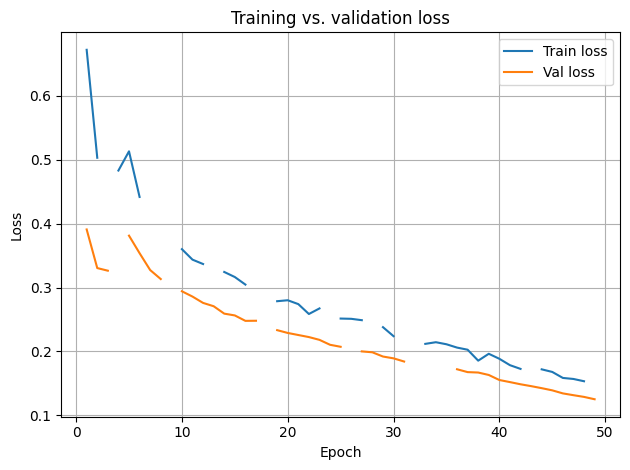

[GPT] Outcomes not in tokenizer vocab (ignored): ['DISGLYCEMIA_EVENT_Hyperglycemia', 'DISGLYCEMIA_EVENT_Hypoglycemia']
[GPT]: Total params: 6.40 M

  pretrain_transformer  |  2026-04-25 17:55:35
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 1, 'dt': 1}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 0.2, 'outcome': 0.2}, 'order': [['ce', 'dt'], ['outcome']], 'ramp_

[Phase-2]: Epoch 00
        --> Train=0.0386 (BCE=0.0386, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0310 (BCE=0.0310, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=0 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 01
        --> Train=0.0413 (BCE=0.0413, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0309 (BCE=0.0309, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=1 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 02
        --> Train=0.0412 (BCE=0.0412, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0307 (BCE=0.0307, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=2 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 03
        --> Train=0.0416 (BCE=0.0416, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0305 (BCE=0.0305, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=3 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


...

[Phase-2]: Epoch 45
        --> Train=0.0413 (BCE=0.0194, CE=0.0217, Out=0.0000, Δt=0.0002)
        --> Val=0.0410 (BCE=0.0170, CE=0.0238, Out=0.0000, Δt=0.0002)
[Scheduler] epoch=45 | ce:λ=0.0295/λ_max=0.0295 | dt:λ=0.0100/λ_max=0.0100 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 46
        --> Train=0.0407 (BCE=0.0194, CE=0.0211, Out=0.0000, Δt=0.0002)
        --> Val=0.0407 (BCE=0.0171, CE=0.0235, Out=0.0000, Δt=0.0002)
[Scheduler] epoch=46 | ce:λ=0.0295/λ_max=0.0295 | dt:λ=0.0100/λ_max=0.0100 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 47
        --> Train=0.0394 (BCE=0.0192, CE=0.0200, Out=0.0000, Δt=0.0002)
        --> Val=0.0401 (BCE=0.0171, CE=0.0228, Out=0.0000, Δt=0.0002)
[Scheduler] epoch=47 | ce:λ=0.0295/λ_max=0.0295 | dt:λ=0.0100/λ_max=0.0100 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 48
        --> Train=0.0395 (BCE=0.0194, CE=0.0199, Out=0.0000, Δt=0.0002)
        --> Val=0.0403 (BCE=0.0171, CE=0.0230, Out=0.0000, Δt=0.0002)
[Scheduler] epoch=48 | ce:λ=0.0295/λ_max=0.0295 | dt:λ=0.0100/λ_max=0.0100 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 49
        --> Train=0.0388 (BCE=0.0193, CE=0.0193, Out=0.0000, Δt=0.0002)
        --> Val=0.0397 (BCE=0.0169, CE=0.0226, Out=0.0000, Δt=0.0002)
[Scheduler] epoch=49 | ce:λ=0.0295/λ_max=0.0295 | dt:λ=0.0100/λ_max=0.0100 | outcome:λ=0.0000(pending)


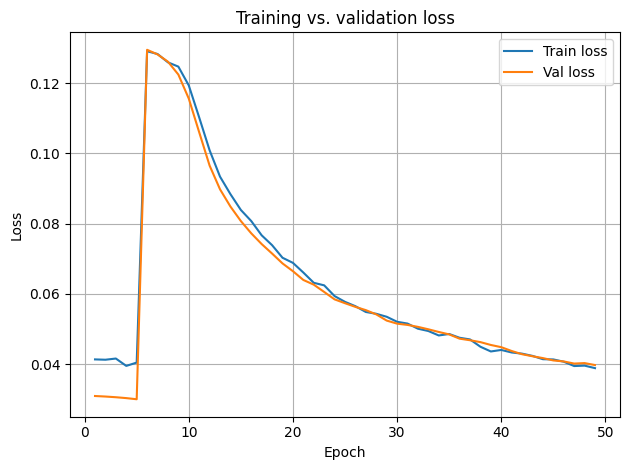


  finetune_transformer  |  2026-04-25 18:08:18
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 1, 'dt': 1}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 0.2, 'outcome': 0.2}, 'order': [['ce', 'dt'], ['outcome']], 'ramp_epochs': {'ce': 1, 'dt': 1, 'outcome': 3}, 'plateau_min_delta': 0.0001, 'plateau_patience': [2]}, 'outcome_decay_tau_hours': 12.0, 'outcome_horizon

[Phase-3]: Epoch 00  train=9.9633  val=7.9878
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 01  train=7.2967  val=6.8249
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 02  train=6.9193  val=6.8325


[Phase-3]: Epoch 03  train=7.1946  val=6.8161
[Phase-3]: Current best model saved.


...

[Phase-3]: Epoch 05  train=6.9635  val=6.8150


[Phase-3]: Epoch 06  train=7.0433  val=6.8180


[Phase-3]: Epoch 07  train=6.8577  val=6.8190


[Phase-3]: Epoch 08  train=7.1016  val=6.8215


[Phase-3]: Epoch 09  train=6.9242  val=6.8225
[Phase-3]: Early stopping triggered.


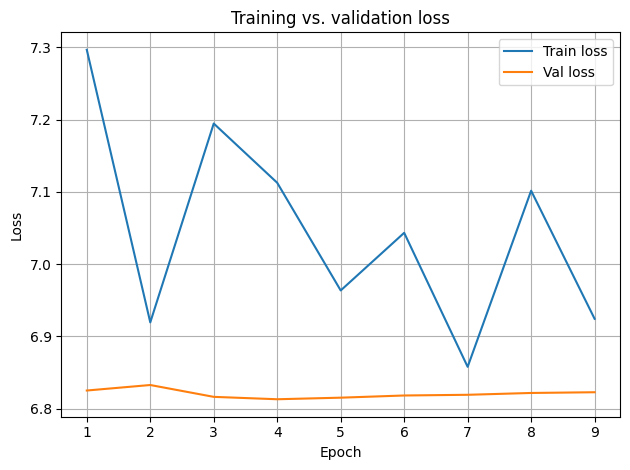

Model ready for evaluation.


In [11]:
def _load_embedder_checkpoint(best_path, tokenizer):
    """Load best Phase-1 checkpoint, falling back to last if best is not yet saved."""
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError(
            "No Phase-1 checkpoint found. Run with RUN_PHASE1=True first."
        )
    print(f"Loading embedder from: {ckpt}")
    model, *_ = embedder.EMREmbedding.load(ckpt, tokenizer=tokenizer)
    return model

def _load_transformer_checkpoint(best_path, embedder_model):
    """Load best Phase-2 checkpoint, falling back to last if best is not yet saved."""
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError(
            "No Phase-2 checkpoint found. Run with RUN_PHASE2=True first."
        )
    print(f"Loading transformer from: {ckpt}")
    model, *_ = transformer.GPT.load(ckpt, embedder=embedder_model)
    return model


# Phase 1: embedder
# RUN_PHASE1=True : always start with a fresh embedder instance.
#   train_embedder() handles checkpoint loading internally when RESUME_TRAINING=True,
#   restoring weights, optimizer, scheduler, and aux-scheduler state.
# RUN_PHASE1=False: load the best available Phase-1 checkpoint directly.

if RUN_PHASE1:
    embedder_model = embedder.EMREmbedding(
        tokenizer=tokenizer,
        ctx_dim=model_config.MODEL_CONFIG.get("ctx_dim"),
        time2vec_dim=model_config.MODEL_CONFIG.get("time2vec_dim"),
        embed_dim=model_config.MODEL_CONFIG.get("embed_dim"),
    )
    embedder_model, _, _ = embedder.train_embedder(
        embedder=embedder_model,
        train_loader=train_dl,
        val_loader=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE1_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    embedder_model = _load_embedder_checkpoint(model_config.PHASE1_CHECKPOINT, tokenizer)


# Phase 2: transformer
# RUN_PHASE2=True : always initialize a fresh GPT instance wrapping the embedder above.
#   pretrain_transformer() handles checkpoint loading internally when RESUME_TRAINING=True.
#   The fresh GPT passed in is discarded on resume -- only its architecture is used.
# RUN_PHASE2=False: load the best available Phase-2 checkpoint directly.

if RUN_PHASE2:
    model = transformer.GPT(cfg=model_config.MODEL_CONFIG, embedder=embedder_model)
    model, _, _ = transformer.pretrain_transformer(
        model=model,
        train_dl=oversampled_train_dl,
        val_dl=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE2_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    model = _load_transformer_checkpoint(model_config.PHASE2_CHECKPOINT, embedder_model)


# Phase 3: outcome head fine-tuning
# Uses natural-distribution batches (oversample=False) so pos_weight in
# BCEWithLogitsLoss correctly compensates for class imbalance without
# double-counting (unlike Phase-2 which uses oversample=True).
# RUN_PHASE3=False: loads Phase-3 checkpoint if available (full GPT.load()),
#   otherwise the Phase-2 outcome head is used as-is.

if RUN_PHASE3:
    model, _, _ = transformer.finetune_transformer(
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE3_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    p3_ckpt = Path(model_config.PHASE3_CHECKPOINT)
    p3_last = p3_ckpt.parent / "ckpt_last.pt"
    p3_path = p3_last if p3_last.exists() else (p3_ckpt if p3_ckpt.exists() else None)
    if p3_path:
        print(f"Loading Phase-3 checkpoint from: {p3_path}")
        model, *_ = transformer.GPT.load(p3_path, embedder=embedder_model)
    else:
        print("No Phase-3 checkpoint found; using outcome head from Phase-2.")

model.eval()
print("Model ready for evaluation.")

## 3) Risk-Based Complication Prediction

Generates a single trajectory per patient (K=1, autoregressive) and reads the outcome head at every step.
This produces a **risk curve** per complication over predicted time.

Evaluation uses **time-stratified AUC**: at each 24 h window the max predicted probability within that
window is compared against whether the complication occurs within that **same 24 h window** in the ground truth.
AUROC and AUPRC are computed per complication then averaged across time windows.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm.auto import tqdm
from pathlib import Path

from transform_emr.inference import generate
from transform_emr.config import dataset_config

# Load best model (safe to re-run independently after a kernel restart)
# Prefers Phase-3 best -> Phase-3 last -> Phase-2 best -> Phase-2 last.
# Requires `tokenizer` to be in scope (run the data cell first).

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _pick_ckpt(*candidates):
    """Return the first existing path among candidates, or None."""
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    return None

_emb_ckpt = _pick_ckpt(model_config.PHASE1_CHECKPOINT,
                        Path(model_config.PHASE1_CHECKPOINT).parent / "ckpt_last.pt")
if _emb_ckpt is None:
    raise FileNotFoundError("No Phase-1 checkpoint found -- run Phase-1 training first.")

_p3_best = Path(model_config.PHASE3_CHECKPOINT)
_p3_last = _p3_best.parent / "ckpt_last.pt"
_p2_best = Path(model_config.PHASE2_CHECKPOINT)
_p2_last = _p2_best.parent / "ckpt_last.pt"
_tfm_ckpt = _pick_ckpt(_p3_best, _p3_last, _p2_best, _p2_last)
if _tfm_ckpt is None:
    raise FileNotFoundError("No Phase-2 or Phase-3 checkpoint found -- run training first.")

print(f"Loading embedder  : {_emb_ckpt}")
_embedder_model, *_ = embedder.EMREmbedding.load(_emb_ckpt, tokenizer=tokenizer,
                                                  map_location=DEVICE)

print(f"Loading transformer: {_tfm_ckpt}")
model, *_ = transformer.GPT.load(_tfm_ckpt, embedder=_embedder_model,
                                  map_location=DEVICE)
model = model.cuda()
model.eval()
print(f"Model ready on {DEVICE}.")

OUTCOME_NAMES = model.outcome_names   # list of outcome token strings
P_COLS        = [f'P_{n}' for n in OUTCOME_NAMES]

Loading embedder  : C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_best.pt
Loading transformer: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_best.pt
[GPT] Outcomes not in tokenizer vocab (ignored): ['DISGLYCEMIA_EVENT_Hyperglycemia', 'DISGLYCEMIA_EVENT_Hypoglycemia']
[GPT]: Total params: 6.40 M
Model ready on cpu.


### 3a) Trained Model Debugging Block

In [ ]:
from transform_emr.diagnose import (
    probe_legality_starvation,
    probe_terminal_logits,
    probe_dt_head,
    probe_outcome_label_alignment,
    probe_calibration_by_abs_time,
    probe_outcome_logit_distribution,
)

probe_legality_starvation(model, val_dl, tokenizer)            # confirms terminals aren't masked at GT positions
probe_terminal_logits(model, val_dl, tokenizer, n_batches=2)   # explains "no natural stop"
probe_dt_head(model, val_dl, n_batches=2)                       # detects Δt collapse
probe_outcome_label_alignment(model, val_dl, tokenizer, n_batches=2)  # finds RELEASE flip
probe_calibration_by_abs_time(model, val_dl, tokenizer, n_batches=2)  # Time2Vec OOD
probe_outcome_logit_distribution(model, val_dl, n_batches=2)   # confirms over-sharp logits

### 3b) Ground Truth Extraction

In [14]:
def extract_ground_truth(dataset):
    """
    For each patient return a dict  outcome_name -> first observed time (hours
    from admission), or np.inf if never observed in the dataset.
    """
    outcome_set = set(OUTCOME_NAMES)
    gt = {}
    for pid in dataset.patient_ids:
        df = dataset.patient_groups[pid]
        patient_gt = {n: np.inf for n in OUTCOME_NAMES}
        tok_col = "PositionToken" if "PositionToken" in df.columns else "Token"
        for _, row in df.iterrows():
            tok_str = row[tok_col]
            if tok_str in outcome_set:
                t = row["TimePoint"]   # already in hours (dataset.py line 955: / 336.0 normalises for model)
                if t < patient_gt[tok_str]:
                    patient_gt[tok_str] = t
        gt[pid] = patient_gt
    return gt


def extract_ground_truth_episodes(dataset):
    """
    For each patient return a dict  outcome_name -> sorted list of ALL observed
    times (hours from admission).  Empty list if the outcome never occurs.
    Used by episode-level AUC evaluation.
    """
    outcome_set = set(OUTCOME_NAMES)
    gt = {}
    for pid in dataset.patient_ids:
        df = dataset.patient_groups[pid]
        patient_gt = {n: [] for n in OUTCOME_NAMES}
        tok_col = "PositionToken" if "PositionToken" in df.columns else "Token"
        for _, row in df.iterrows():
            tok_str = row[tok_col]
            if tok_str in outcome_set:
                patient_gt[tok_str].append(row["TimePoint"])   # already in hours
        gt[pid] = patient_gt
    return gt


# dataset_test has full (untruncated) sequences -> use for ground truth
gt_labels          = extract_ground_truth(eval_ds)           # first occurrence, for MAE / calibration
gt_labels_episodes = extract_ground_truth_episodes(eval_ds)  # all episodes, for AUC

print(f"Ground truth extracted for {len(gt_labels)} patients.")

import pandas as pd
summary = {n: sum(1 for p in gt_labels if gt_labels[p][n] < np.inf) for n in OUTCOME_NAMES}
pd.Series(summary, name="patients_with_complication").sort_values(ascending=False)

Ground truth extracted for 100 patients.


DEATH_EVENT                         91
ACUTE_RESPIRATORY_DISORDER_EVENT    36
ATHEROSCLEROSIS_EVENT               36
HYPEROSMOLALITY_EVENT               35
NERVOUS_SYSTEM_DISORDER_EVENT       33
OTHER_COMPLICATION_EVENT            33
KIDNEY_COMPLICATION_EVENT           33
NEUROVASCULAR_COMPLICATION_EVENT    32
RETINOPATHY_EVENT                   32
SKIN_ULCER_EVENT                    31
INFECTION_EVENT                     31
DIABETIC_COMA_EVENT                 29
ACIDOSIS_EVENT                      28
KETOACIDOSIS_EVENT                  24
CARDIO-VASCULAR_DISORDER_EVENT      23
RELEASE_EVENT                        9
Name: patients_with_complication, dtype: int64

### 3c) Generate Risk Curves

In [ ]:
# Build truncated eval dataset using the same input-day cutoff as Phase-3 training.
# This ensures the outcome head sees the same context distribution it was aligned on.
EVAL_INPUT_DAYS = 2   # days of patient history used as input for Phase-3 generation
print(f"Building truncated eval dataset ({EVAL_INPUT_DAYS}-day input window)...")
eval_input_processor = dataset.DataProcessor(
    eval_temporal_raw.copy(),
    eval_ctx_raw.copy(),
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
    max_input_days=EVAL_INPUT_DAYS,
)
eval_input_temporal_df, eval_input_ctx_df = eval_input_processor.run()
eval_ds_input = dataset.EMRDataset(eval_input_temporal_df, eval_input_ctx_df, tokenizer=tokenizer)

risk_df = generate(
    model, eval_ds_input,
    max_len=500,
    temperature=1.0,
    top_k=None,
    rep_decay=0.6,
    collect_risk_scores=True,
)
print(f'Risk curves: {len(risk_df)} rows, {risk_df["PatientId"].nunique()} patients.')
risk_df.head()

Building truncated eval dataset (2-day input window)...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 31254 -> 31254
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 31254 -> 27852


[generate] INFO  21/21 (100.0%) patient(s) reached max_len=500 without a natural terminal — forced terminal injected.
Risk curves: 12231 rows, 21 patients.


,PatientId,Step,TimePoint,Token,IsInput,IsOutcome,IsTerminal,P_ACIDOSIS_EVENT,P_ACUTE_RESPIRATORY_DISORDER_EVENT,P_ATHEROSCLEROSIS_EVENT,...,P_HYPEROSMOLALITY_EVENT,P_INFECTION_EVENT,P_KETOACIDOSIS_EVENT,P_KIDNEY_COMPLICATION_EVENT,P_NERVOUS_SYSTEM_DISORDER_EVENT,P_NEUROVASCULAR_COMPLICATION_EVENT,P_OTHER_COMPLICATION_EVENT,P_RELEASE_EVENT,P_RETINOPATHY_EVENT,P_SKIN_ULCER_EVENT
0,12,1,0.000000,ADMISSION_EVENT,1,0,0,0.204488,0.231441,0.213587,...,0.216352,0.203041,0.224868,0.210416,0.173580,0.246445,0.196543,0.182158,0.208983,0.227039
1,12,2,2.043333,BLOOD_PRESSURE_DIASTOLIC_MEASURE_STATE_Low_START,1,0,0,0.163079,0.182330,0.167598,...,0.170475,0.152127,0.166081,0.169876,0.134131,0.194675,0.158902,0.146016,0.167249,0.182616
2,12,3,2.139722,BODY_TEMPERATURE_MEASURE_TREND_INC_START,1,0,0,0.164604,0.186104,0.168066,...,0.175284,0.159303,0.174903,0.164926,0.137558,0.197454,0.154370,0.147660,0.168020,0.180588
3,12,4,3.501389,KIDNEY_COMPLICATION_EVENT,1,1,0,0.150460,0.163430,0.144288,...,0.158444,0.135737,0.154961,0.148039,0.118708,0.176429,0.138673,0.134400,0.152048,0.163419
4,12,5,3.867778,BLOOD_PRESSURE_DIASTOLIC_MEASURE_STATE_Low_END,1,0,0,0.149611,0.164342,0.148001,...,0.155413,0.138706,0.153327,0.149468,0.118850,0.176961,0.142602,0.131813,0.150310,0.167088


### 3d) Episode-Level Pooled AUC

Each patient's generated trajectory is split into non-overlapping 24 h windows.
For each (patient, window) pair:
- **score** = max outcome-head probability within the window
- **label** = 1 if any ground-truth episode of the complication falls within
  +/-24 h of the window boundaries (grace window prevents penalising predictions
  adjacent to a real event)

All (patient, window) pairs are pooled and a single AUROC / AUPRC is computed
per outcome.  Multiple episodes of the same complication (e.g., three hypoglycaemia
events) each contribute independent positive windows.

In [17]:
def pooled_episode_auc(risk_df, gt_labels_episodes, outcome_names,
                        window_hours=24.0, grace_hours=24.0, min_positives=3):
    """
    Episode-level AUROC/AUPRC pooled across all (patient, window) pairs.

    Each patient's generated trajectory is divided into non-overlapping windows of
    window_hours.  For each window:
      score = max P_outcome within the window (per patient)
      label = 1 if any ground-truth episode of the outcome falls in
              [t_win_start - grace_hours, t_win_end + grace_hours]

    The grace window prevents penalising a window adjacent to an episode
    (the model's prediction may spill one window past the actual event time).
    At most ceil(2*grace_hours / window_hours) + 1 consecutive windows are
    positive per episode.

    All (patient, window) pairs are pooled into one AUROC/AUPRC per outcome,
    so rare outcomes and terminal events are handled gracefully -- no per-window
    min-support is required.

    Args:
        risk_df (pd.DataFrame): Output of generate_risk_curves().
        gt_labels_episodes (dict): {pid: {outcome: [t1, t2, ...]}} all episode times.
        outcome_names (list[str]): Outcome names to evaluate.
        window_hours (float): Duration of each evaluation window in hours.
        grace_hours (float): Extra tolerance added to each window edge for labelling.
        min_positives (int): Skip outcome if fewer than this many positive windows exist.

    Returns:
        pd.DataFrame indexed by outcome with columns:
            auroc, auprc, n_pos_windows, n_neg_windows.
    """
    gen_df = risk_df[risk_df["IsInput"] == 0].copy()
    p_cols = [f"P_{n}" for n in outcome_names]

    t_min = gen_df["TimePoint"].min()
    gen_df["_win"] = np.floor((gen_df["TimePoint"] - t_min) / window_hours).astype(int)

    # max risk per (patient, window) -- vectorised
    peak = (gen_df
            .groupby(["PatientId", "_win"])[p_cols]
            .max()
            .reset_index())
    peak["_t_start"] = t_min + peak["_win"] * window_hours
    peak["_t_end"]   = peak["_t_start"] + window_hours

    rows = []
    for name in outcome_names:
        pcol = f"P_{name}"
        scores, labels = [], []

        for _, row in peak.iterrows():
            pid     = row["PatientId"]
            t_lo    = row["_t_start"] - grace_hours
            t_hi    = row["_t_end"]   + grace_hours
            episodes = gt_labels_episodes.get(pid, {}).get(name, [])
            label   = int(any(t_lo <= ep <= t_hi for ep in episodes))
            scores.append(row[pcol])
            labels.append(label)

        labels = np.array(labels)
        scores = np.array(scores)
        n_pos  = int(labels.sum())
        n_neg  = int((1 - labels).sum())

        if n_pos < min_positives:
            rows.append({"outcome": name, "auroc": np.nan, "auprc": np.nan,
                         "n_pos_windows": n_pos, "n_neg_windows": n_neg})
            continue

        rows.append({
            "outcome":       name,
            "auroc":         roc_auc_score(labels, scores),
            "auprc":         average_precision_score(labels, scores),
            "n_pos_windows": n_pos,
            "n_neg_windows": n_neg,
        })

    return pd.DataFrame(rows).set_index("outcome").sort_values("auroc", ascending=False)


auc_results = pooled_episode_auc(
    risk_df, gt_labels_episodes, OUTCOME_NAMES,
    window_hours=24.0,
    grace_hours=24.0,
)
print(f"Mean AUROC across complications: {auc_results['auroc'].mean():.3f}")
print(f"Mean AUPRC across complications: {auc_results['auprc'].mean():.3f}")
auc_results.round(3)

Mean AUROC across complications: 0.715
Mean AUPRC across complications: 0.205


,auroc,auprc,n_pos_windows,n_neg_windows
outcome,,,,
CARDIO-VASCULAR_DISORDER_EVENT,0.791,0.348,12,246
RELEASE_EVENT,0.783,0.130,13,245
OTHER_COMPLICATION_EVENT,0.772,0.207,24,234
ACIDOSIS_EVENT,0.755,0.308,19,239
KETOACIDOSIS_EVENT,0.753,0.237,21,237
ATHEROSCLEROSIS_EVENT,0.753,0.233,26,232
NEUROVASCULAR_COMPLICATION_EVENT,0.744,0.221,22,236
SKIN_ULCER_EVENT,0.731,0.271,10,248
ACUTE_RESPIRATORY_DISORDER_EVENT,0.714,0.121,15,243


### 3d-ii) Time Accuracy (MAE on Onset Prediction)

For patients where a complication actually occurred, compare the **predicted onset time**
(TimePoint of the generated step where outcome probability peaked) against the **actual onset time**.
Reports Mean Absolute Error in hours per complication.

In [18]:
def time_accuracy(risk_df, gt_labels, outcome_names):
    """
    For each complication, for patients where it occurred:
      predicted onset = TimePoint of the generated step with peak P_<outcome>
      actual onset    = first occurrence time from ground truth
    Returns MAE in hours per complication.
    """
    gen_df = risk_df[risk_df['IsInput'] == 0].copy()

    # for each patient, find the TimePoint of peak probability for each outcome at once
    p_cols = [f'P_{n}' for n in outcome_names]
    idxmax = gen_df.groupby('PatientId')[p_cols].idxmax()          # pid â†’ row index of peak
    peak_times = gen_df.loc[:, ['PatientId', 'TimePoint']].copy()

    rows = []
    for name in outcome_names:
        pcol = f'P_{name}'
        # map patient â†’ predicted onset time
        pred_t = gen_df.loc[idxmax[pcol].dropna().astype(int), ['PatientId', 'TimePoint']]
        pred_t = pred_t.set_index('PatientId')['TimePoint']

        errors = []
        for pid, pt in pred_t.items():
            gt_t = gt_labels.get(pid, {}).get(name, np.inf)
            if gt_t == np.inf:
                continue
            errors.append(abs(pt - gt_t))

        rows.append({
            'outcome':    name,
            'mae_hours':  np.mean(errors) if errors else np.nan,
            'n_patients': len(errors),
        })
    return pd.DataFrame(rows).set_index('outcome').sort_values('mae_hours')


time_acc = time_accuracy(risk_df, gt_labels, OUTCOME_NAMES)
print(f'Mean MAE across complications with occurrences: {time_acc["mae_hours"].mean():.1f} h')
time_acc.round(1)

Mean MAE across complications with occurrences: 53.6 h


,mae_hours,n_patients
outcome,,
RETINOPATHY_EVENT,31.1,9
ACUTE_RESPIRATORY_DISORDER_EVENT,45.8,11
DEATH_EVENT,47.5,15
OTHER_COMPLICATION_EVENT,48.2,16
CARDIO-VASCULAR_DISORDER_EVENT,51.8,9
ACIDOSIS_EVENT,52.2,11
ATHEROSCLEROSIS_EVENT,52.7,15
KETOACIDOSIS_EVENT,53.0,10
INFECTION_EVENT,54.3,13


### 3e) Temperature Scaling Calibration

Learns one temperature scalar `T` per outcome by minimising NLL on the test set.
Using `logits / T` before sigmoid shrinks (T > 1) or sharpens (T < 1) probabilities
without changing rank order  so AUROC is unaffected, but calibration curves improve.

**When you need this**: when you want to interpret probability values (e.g. 'this patient
has a 70% chance of hyperglycemia') rather than just rank patients by risk.

In [19]:
def calibrate_temperature(model, dataset, gt_labels, outcome_names,
                           n_iter=200, lr=0.05):
    """
    Teacher-forced forward pass on the full (untruncated) test sequences.
    For each patient, takes the outcome-head logit at the *last real token*
    as the pre-calibration score, then learns T per outcome via LBFGS.

    Returns
    -------
    temperatures : dict  outcome_name -> float T
    cal_data     : dict  outcome_name -> (logits_np, labels_np)
    """
    device = next(model.parameters()).device
    tok    = model.embedder.tokenizer

    all_logits = {n: [] for n in outcome_names}
    all_labels = {n: [] for n in outcome_names}

    model.eval()
    with torch.no_grad():
        for pid in tqdm(dataset.patient_ids, desc='Collecting logits'):
            df      = dataset.patient_groups[pid]
            ctx_vec = torch.tensor(dataset.context_df.loc[pid].values,
                                   dtype=torch.float32).unsqueeze(0).to(device)
            pos_ids        = torch.tensor([df['PositionID'].tolist()], dtype=torch.long, device=device)
            parent_raw_ids = tok.tokenid2parent_raw_ids[pos_ids[0]].unsqueeze(0).to(device)
            concept_ids    = torch.tensor([df['ConceptID'].tolist()],  dtype=torch.long, device=device)
            value_ids      = torch.tensor([df['ValueID'].tolist()],    dtype=torch.long, device=device)
            abs_ts         = torch.tensor([df['TimePoint'].tolist()],  dtype=torch.float32, device=device) / 336.0

            _, _, outcome_logits, _ = model(
                parent_raw_ids=parent_raw_ids, concept_ids=concept_ids,
                value_ids=value_ids, position_ids=pos_ids,
                abs_ts=abs_ts, context_vec=ctx_vec
            )
            last_logit = outcome_logits[0, -1, :].cpu()  # [num_outcomes]

            for i, name in enumerate(outcome_names):
                gt_t  = gt_labels.get(pid, {}).get(name, np.inf)
                label = int(gt_t < np.inf)  # ever occurred?
                all_logits[name].append(last_logit[i].item())
                all_labels[name].append(label)

    temperatures = {}
    cal_data     = {}
    for name in outcome_names:
        logits_t = torch.tensor(all_logits[name], dtype=torch.float32)
        labels_t = torch.tensor(all_labels[name], dtype=torch.float32)
        if labels_t.sum() < 2:
            temperatures[name] = 1.0
            cal_data[name] = (logits_t.numpy(), labels_t.numpy())
            continue
        T = nn.Parameter(torch.ones(1))
        opt = torch.optim.LBFGS([T], lr=lr, max_iter=n_iter)
        def closure():
            opt.zero_grad()
            loss = nn.functional.binary_cross_entropy_with_logits(logits_t / T, labels_t)
            loss.backward()
            return loss
        opt.step(closure)
        temperatures[name] = T.item()
        cal_data[name] = (logits_t.detach().numpy(), labels_t.numpy())

    return temperatures, cal_data


# calibrate on the FULL test sequences (eval_ds)
temperatures, cal_data = calibrate_temperature(model, eval_ds, gt_labels, OUTCOME_NAMES)
pd.Series(temperatures, name='temperature_T').sort_values()

RELEASE_EVENT                        0.756657
CARDIO-VASCULAR_DISORDER_EVENT       1.622744
KETOACIDOSIS_EVENT                   1.661432
ACIDOSIS_EVENT                       1.921644
DIABETIC_COMA_EVENT                  1.996614
NEUROVASCULAR_COMPLICATION_EVENT     2.278542
SKIN_ULCER_EVENT                     2.301634
RETINOPATHY_EVENT                    2.385269
INFECTION_EVENT                      2.555942
KIDNEY_COMPLICATION_EVENT            2.620162
OTHER_COMPLICATION_EVENT             2.640872
NERVOUS_SYSTEM_DISORDER_EVENT        2.806769
HYPEROSMOLALITY_EVENT                2.958404
ACUTE_RESPIRATORY_DISORDER_EVENT     3.404931
ATHEROSCLEROSIS_EVENT                3.491274
DEATH_EVENT                         85.474007
Name: temperature_T, dtype: float64

### 3f) Reliability Diagram (before / after calibration)

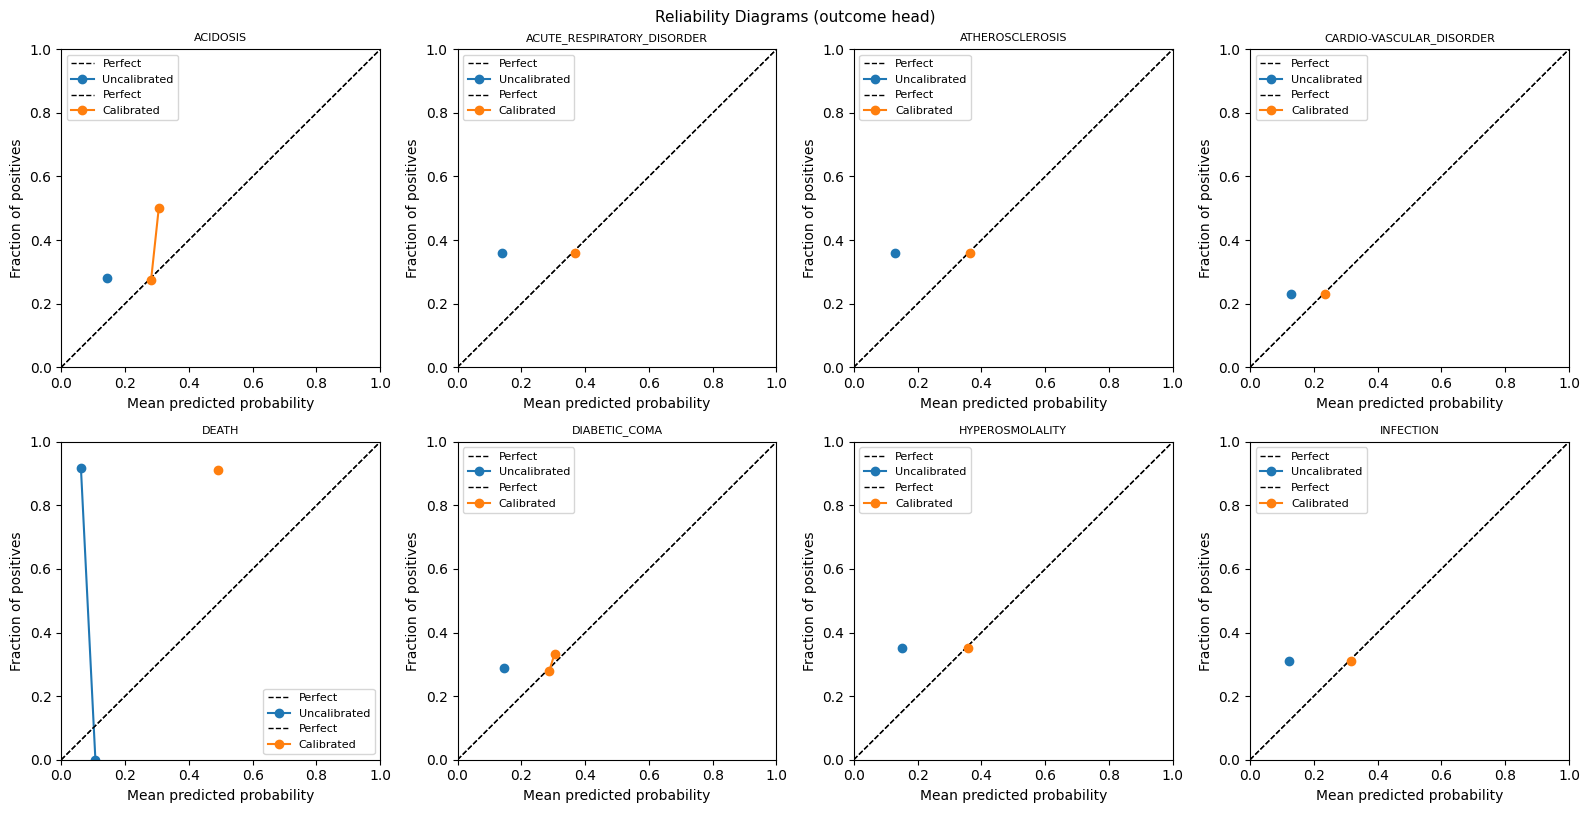

In [20]:
def reliability_diagram(ax, logits, labels, T=1.0, n_bins=10, label=''):
    probs = torch.sigmoid(torch.tensor(logits) / T).numpy()
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, mean_true = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_centers.append(probs[mask].mean())
            mean_true.append(labels[mask].mean())
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.plot(bin_centers, mean_true, 'o-', label=label)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

# Plot outcomes that have enough positives
eligible = [n for n in OUTCOME_NAMES if cal_data[n][1].sum() >= 5]
n_plots  = min(len(eligible), 8)
fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(4 * ((n_plots + 1) // 2), 8))
axes = axes.flatten()
for ax, name in zip(axes, eligible[:n_plots]):
    logits_np, labels_np = cal_data[name]
    ax.set_title(name.replace('_EVENT', '').replace('_COMPLICATION', ''), fontsize=8)
    reliability_diagram(ax, logits_np, labels_np, T=1.0,            label='Uncalibrated')
    reliability_diagram(ax, logits_np, labels_np, T=temperatures[name], label='Calibrated')
for ax in axes[n_plots:]:
    ax.set_visible(False)
plt.tight_layout()
plt.suptitle('Reliability Diagrams (outcome head)', y=1.01, fontsize=11)
plt.show()

### 3g) Sample Patient Risk Curve

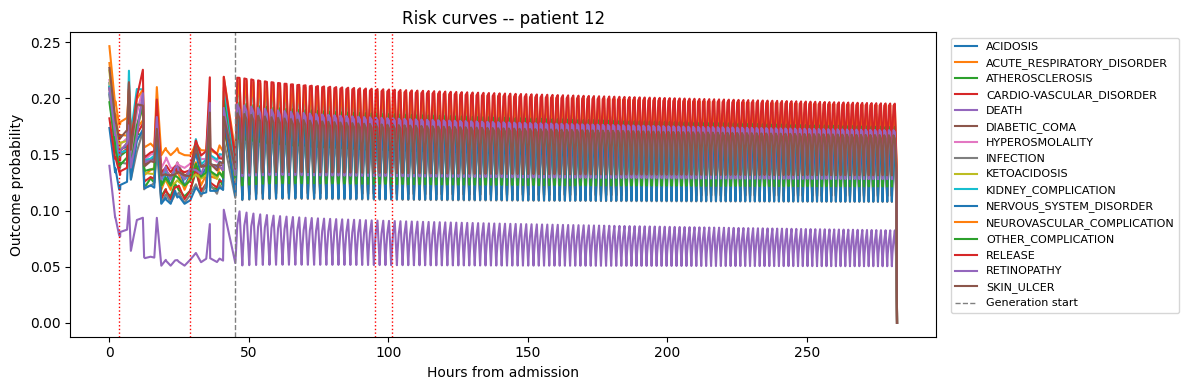

In [21]:
# Visualise the risk trajectory for one patient over time.
# Change `sample_pid` to inspect a specific patient.
sample_pid = risk_df['PatientId'].iloc[0]
patient_risk = risk_df[risk_df['PatientId'] == sample_pid].copy()

# Outcomes that actually have some signal for this patient
gen_risk = patient_risk[patient_risk['IsInput'] == 0]
active = [n for n in OUTCOME_NAMES if gen_risk[f'P_{n}'].max() > 0.05]
if not active:
    active = OUTCOME_NAMES[:4]  # fallback: show first four

fig, ax = plt.subplots(figsize=(12, 4))
for name in active:
    ax.plot(patient_risk['TimePoint'], patient_risk[f'P_{name}'], label=name.replace('_EVENT',''), lw=1.5)

# Mark where input ends
input_end = patient_risk[patient_risk['IsInput'] == 1]['TimePoint'].max()
ax.axvline(input_end, color='gray', linestyle='--', lw=1, label='Generation start')

# Mark actual ground truth occurrences (if patient in gt_labels)
if sample_pid in gt_labels:
    for name, t in gt_labels[sample_pid].items():
        if t < np.inf and name in active:
            ax.axvline(t, color='red', linestyle=':', lw=1)

ax.set_xlabel('Hours from admission')
ax.set_ylabel('Outcome probability')
ax.set_title(f'Risk curves -- patient {sample_pid}')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()